# 4. Posterior Analysis — Model 2 (Student-t Likelihood, log-time)

## Model Specification

Like Model 1, we model the **logarithm** of finish time, $y_i = \log(T_i)$, and add a **steepness**
predictor (elevation gain per km). The likelihood is Student-t for robustness against outlier races.

$$\log(T_i) \sim \text{Student-t}(\nu, \mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist}\,\text{distance\_log\_std}_i + \beta_{elev}\,\text{elevation\_log\_std}_i + \beta_{steep}\,\text{steepness\_std}_i$$

**Priors (log-time scale):**
- $\alpha \sim \text{Normal}(\log 10,\ 0.5)$
- $\beta_{dist} \sim \text{Normal}(0.6,\ 0.3)$
- $\beta_{elev} \sim \text{Normal}(0.2,\ 0.25)$
- $\beta_{steep} \sim \text{Normal}(0.15,\ 0.25)$ — $e^{0.15}\approx1.16\times$ per +1 SD steepness
- $\sigma \sim \text{Half-Normal}(0,\ 0.35)$
- $\nu = 2 + \nu_{-2}$, with $\nu_{-2} \sim \text{Gamma}(2,\ 0.1)$ — guarantees $\nu>2$ (finite variance) and keeps mass away from $\nu=2$ for lighter tails

### Why Student-t on the log scale?

The Student-t distribution has heavier polynomial tails than the Normal. On the log scale this means:
- Outlier races (technical terrain, extreme weather, data errors, atypical profiles) don't inflate $\sigma$ for all races.
- The model assigns non-negligible probability to extreme log-times without widening the bulk of the distribution.
- As $\nu \to \infty$ it reduces to the Normal log-time model (so it nests Model 1).
- Modelling `log_time` keeps every back-transformed prediction `time_rep = exp(log_time_rep)` strictly positive.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110

# Load processed data
df_full = pd.read_csv('utmb_processed.csv')

# --- Log-time feature engineering (standardize on full cleaned data, then subsample) ---
df_full = df_full[(df_full['Mean Finish Time'] > 0) &
                  (df_full['Distance'] > 0) &
                  (df_full['Elevation Gain'] >= 0)].copy()

df_full['log_time'] = np.log(df_full['Mean Finish Time'])
df_full['log_distance'] = np.log(df_full['Distance'])
df_full['log_elevation'] = np.log(df_full['Elevation Gain'] + 1)
df_full['steepness'] = df_full['Elevation Gain'] / df_full['Distance']

def standardise(s): return (s - s.mean()) / s.std()
df_full['distance_log_std']  = standardise(df_full['log_distance'])
df_full['elevation_log_std'] = standardise(df_full['log_elevation'])
df_full['log_steepness']     = np.log1p(df_full['steepness'])
df_full['steepness_std']     = standardise(df_full['log_steepness'])
if 'Elevation' in df_full.columns:
    df_full['altitude_std'] = standardise(df_full['Elevation'])
else:
    df_full['altitude_std'] = 0.0

# Subsample for computational feasibility
df = df_full.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Data: {df.shape[0]:,} observations (subsampled from {df_full.shape[0]:,})")
print(f"Categories: {df['Race Category'].value_counts().to_dict()}")

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data: 5,000 observations (subsampled from 36,433)
Categories: {'50K': 2101, '20K': 1503, '100K': 1016, '100M': 380}


In [2]:
# Prepare Stan data (response = log_time; unified 4-predictor model)
stan_data = {
    'N': len(df),
    'log_time':           df['log_time'].values.tolist(),
    'distance_log_std':   df['distance_log_std'].values.tolist(),
    'elevation_log_std':  df['elevation_log_std'].values.tolist(),
    'steepness_std':      df['steepness_std'].values.tolist(),
    'altitude_std':       df['altitude_std'].values.tolist(),
}

# Compile and fit Model 2
model2 = CmdStanModel(stan_file='model2_student_t.stan')
print("Model 2 (Student-t, log-time) compiled.")

INFO:cmdstanpy:compiling stan file /home/utmb_race_finish_times_bayesian_analysis/model2_student_t.stan to exe file /home/utmb_race_finish_times_bayesian_analysis/model2_student_t
INFO:cmdstanpy:compiled model executable: /home/utmb_race_finish_times_bayesian_analysis/model2_student_t


Model 2 (Student-t, log-time) compiled.


In [3]:
# Fit Model 2
fit2 = model2.sample(
    data=stan_data,
    chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    seed=42,
    show_progress=True
)
print("Sampling complete.")

INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status


chain 1 |▉         | 00:04 Iteration:    1 / 2000 [  0%]  (Warmup)





chain 1 |█▎        | 00:17 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 00:28 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 00:37 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 00:47 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 00:55 Iteration:  500 / 2000 [ 25%]  (Warmup)




chain 1 |███▋      | 01:03 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 01:10 Iteration:  700 / 2000 [ 35%]  (Warmup)
chain 1 |████▌     | 01:17 Iteration:  800 / 2000 [ 40%]  (Warmup)


chain 1 |█████▍    | 01:29 Iteration: 1000 / 2000 [ 50%]  (Warmup)


chain 1 |█████▉    | 01:43 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 01:56 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 02:08 Iteration: 1200 / 2000 [ 6


INFO:cmdstanpy:CmdStan done processing.



Sampling complete.


## 4.1 Sampling Diagnostics

The Student-t model has one additional parameter ($\nu$) compared to the Normal model. We check the same diagnostics:
- R-hat < 1.01
- ESS > 400
- 0 divergences
- Well-mixed trace plots

In [4]:
# Convert to ArviZ InferenceData (log-time scale)
idata2 = az.from_cmdstanpy(
    fit2,
    posterior_predictive='log_time_rep',
    log_likelihood='log_lik',
    observed_data={'log_time': df['log_time'].values}
)

# Print summary
print("=" * 70)
print("MODEL 2 (Student-t, log-time) — Posterior Summary")
print("=" * 70)
summary2 = az.summary(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma', 'nu'])
print(summary2.to_string())

MODEL 2 (Student-t, log-time) — Posterior Summary
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha       2.086  0.003   2.081    2.090      0.000    0.000    3052.0    2494.0    1.0
beta_dist   2.052  0.102   1.848    2.226      0.003    0.002    1042.0    1446.0    1.0
beta_elev  -1.565  0.120  -1.774   -1.331      0.004    0.003    1041.0    1448.0    1.0
beta_steep  1.273  0.087   1.102    1.422      0.003    0.002    1041.0    1452.0    1.0
sigma       0.150  0.003   0.144    0.155      0.000    0.000    1591.0    2010.0    1.0
nu          5.753  0.503   4.855    6.711      0.013    0.009    1577.0    1735.0    1.0


In [5]:
# Diagnostics
print("\n=== MCMC Diagnostics ===")
divergences = fit2.diagnose()
print(divergences)


=== MCMC Diagnostics ===
Processing csv files: /tmp/tmp2zo45o1k/model2_student_t-20260531161000_1.csv, /tmp/tmp2zo45o1k/model2_student_t-20260531161000_2.csv, /tmp/tmp2zo45o1k/model2_student_t-20260531161000_3.csv, /tmp/tmp2zo45o1k/model2_student_t-20260531161000_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



In [6]:
# R-hat and ESS
rhat_vals = summary2['r_hat'].values
ess_bulk_vals = summary2['ess_bulk'].values
ess_tail_vals = summary2['ess_tail'].values

print("R-hat values:")
for param, rhat in zip(summary2.index, rhat_vals):
    status = '✓' if rhat < 1.01 else '✗ WARNING'
    print(f"  {param}: {rhat:.4f} {status}")

print(f"\nESS bulk (min): {ess_bulk_vals.min():.0f} {'✓' if ess_bulk_vals.min() > 400 else '✗ WARNING'}")
print(f"ESS tail (min): {ess_tail_vals.min():.0f} {'✓' if ess_tail_vals.min() > 400 else '✗ WARNING'}")

print(f"\nAll R-hat < 1.01: {all(rhat_vals < 1.01)}")
print(f"All ESS_bulk > 400: {all(ess_bulk_vals > 400)}")
print(f"All ESS_tail > 400: {all(ess_tail_vals > 400)}")

print(f"\nNote: The nu parameter may have lower ESS due to weaker identification.")
print(f"This is expected — nu is only informed by the tails of the data.")

R-hat values:
  alpha: 1.0000 ✓
  beta_dist: 1.0000 ✓
  beta_elev: 1.0000 ✓
  beta_steep: 1.0000 ✓
  sigma: 1.0000 ✓
  nu: 1.0000 ✓

ESS bulk (min): 1041 ✓
ESS tail (min): 1446 ✓

All R-hat < 1.01: True
All ESS_bulk > 400: True
All ESS_tail > 400: True

Note: The nu parameter may have lower ESS due to weaker identification.
This is expected — nu is only informed by the tails of the data.


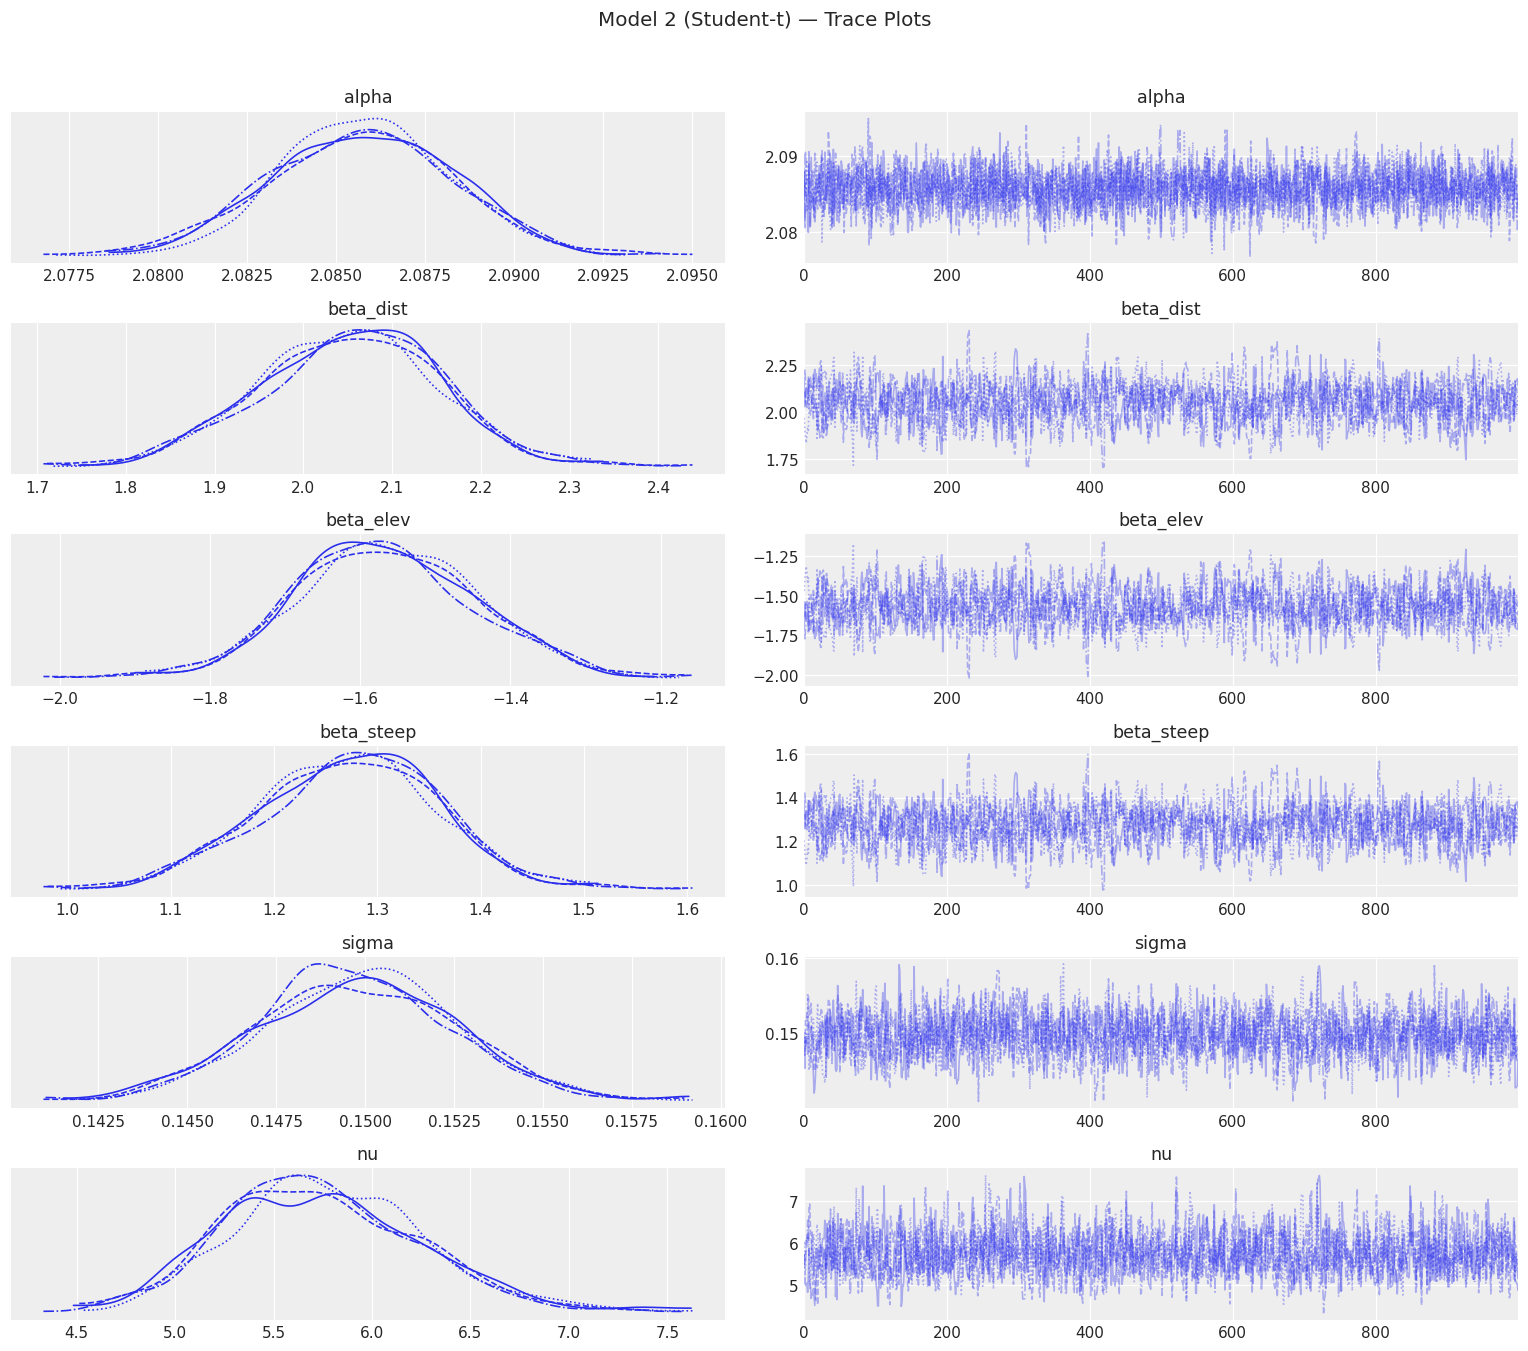


Trace plot assessment:
  → All chains should be well-mixed
  → nu trace may show more autocorrelation (normal for df parameter)


In [7]:
# Trace plots
fig = az.plot_trace(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma', 'nu'],
                    figsize=(14, 12), compact=True)
plt.suptitle('Model 2 (Student-t) — Trace Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig11_model2_trace.png', bbox_inches='tight')
plt.show()

print("\nTrace plot assessment:")
print("  → All chains should be well-mixed")
print("  → nu trace may show more autocorrelation (normal for df parameter)")

### Sampling Assessment

The Student-t model may have slightly lower ESS for $\nu$ because:
- $\nu$ is only informed by observations in the tails
- It can be weakly identified when there are few extreme values

**Mitigation if issues arise:**
- If low ESS for $\nu$: increase `iter_sampling` to 4000
- If divergences: increase `adapt_delta` to 0.95
- If $\nu$ is very large (>50): the data doesn't support heavy tails, Normal model is sufficient

## 4.2 Posterior Predictive Distribution

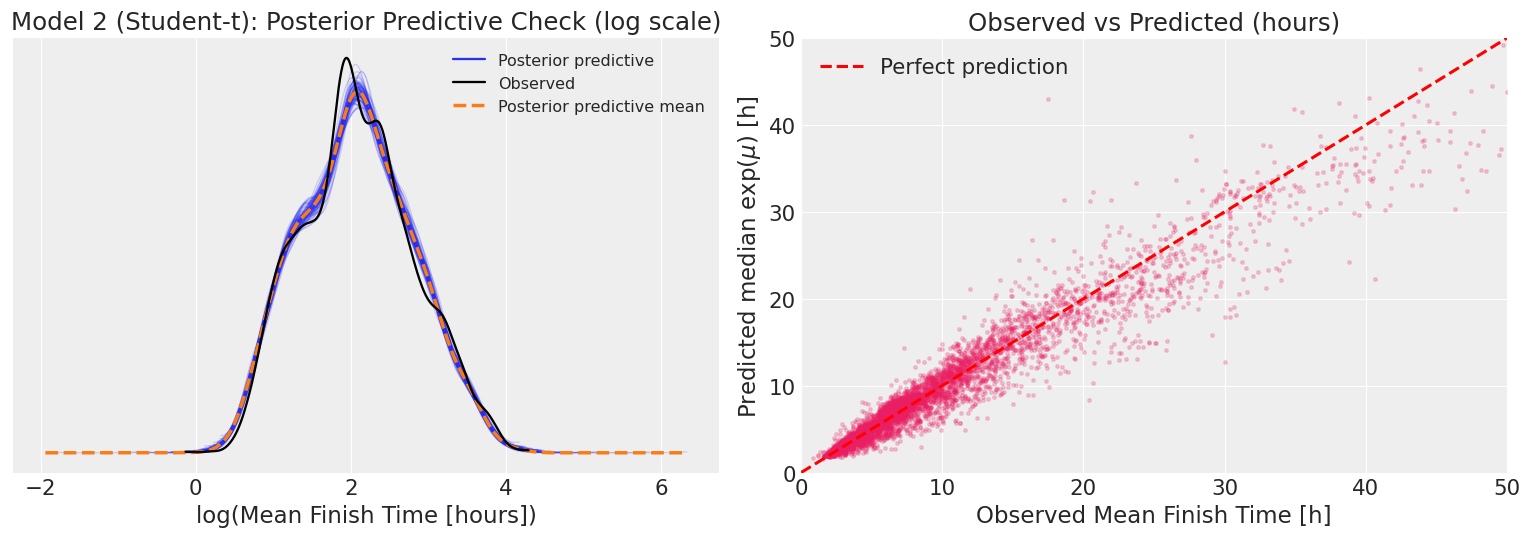

In [8]:
# Posterior predictive check — overall (log scale + back-transformed hours)
y_obs = df['Mean Finish Time'].values
log_obs = df['log_time'].values

time_rep_samples = fit2.stan_variable('time_rep')        # (draws, N) hours
time_mu_samples = fit2.stan_variable('time_mu')          # (draws, N) median hours
log_time_rep_samples = fit2.stan_variable('log_time_rep')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PPC on the LOG scale (where the Student-t likelihood lives)
az.plot_ppc(idata2, data_pairs={'log_time': 'log_time_rep'}, num_pp_samples=100, ax=axes[0])
axes[0].set_title('Model 2 (Student-t): Posterior Predictive Check (log scale)')
axes[0].set_xlabel('log(Mean Finish Time [hours])')

# Right: observed vs predicted in HOURS (point prediction = posterior mean of exp(mu))
pred_hours = time_mu_samples.mean(axis=0)
axes[1].scatter(y_obs, pred_hours, alpha=0.2, s=5, color='#E91E63')
axes[1].plot([0, 50], [0, 50], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Observed Mean Finish Time [h]')
axes[1].set_ylabel('Predicted median exp($\\mu$) [h]')
axes[1].set_title('Observed vs Predicted (hours)')
axes[1].legend()
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.savefig('fig12_model2_ppc_overall.png', bbox_inches='tight')
plt.show()

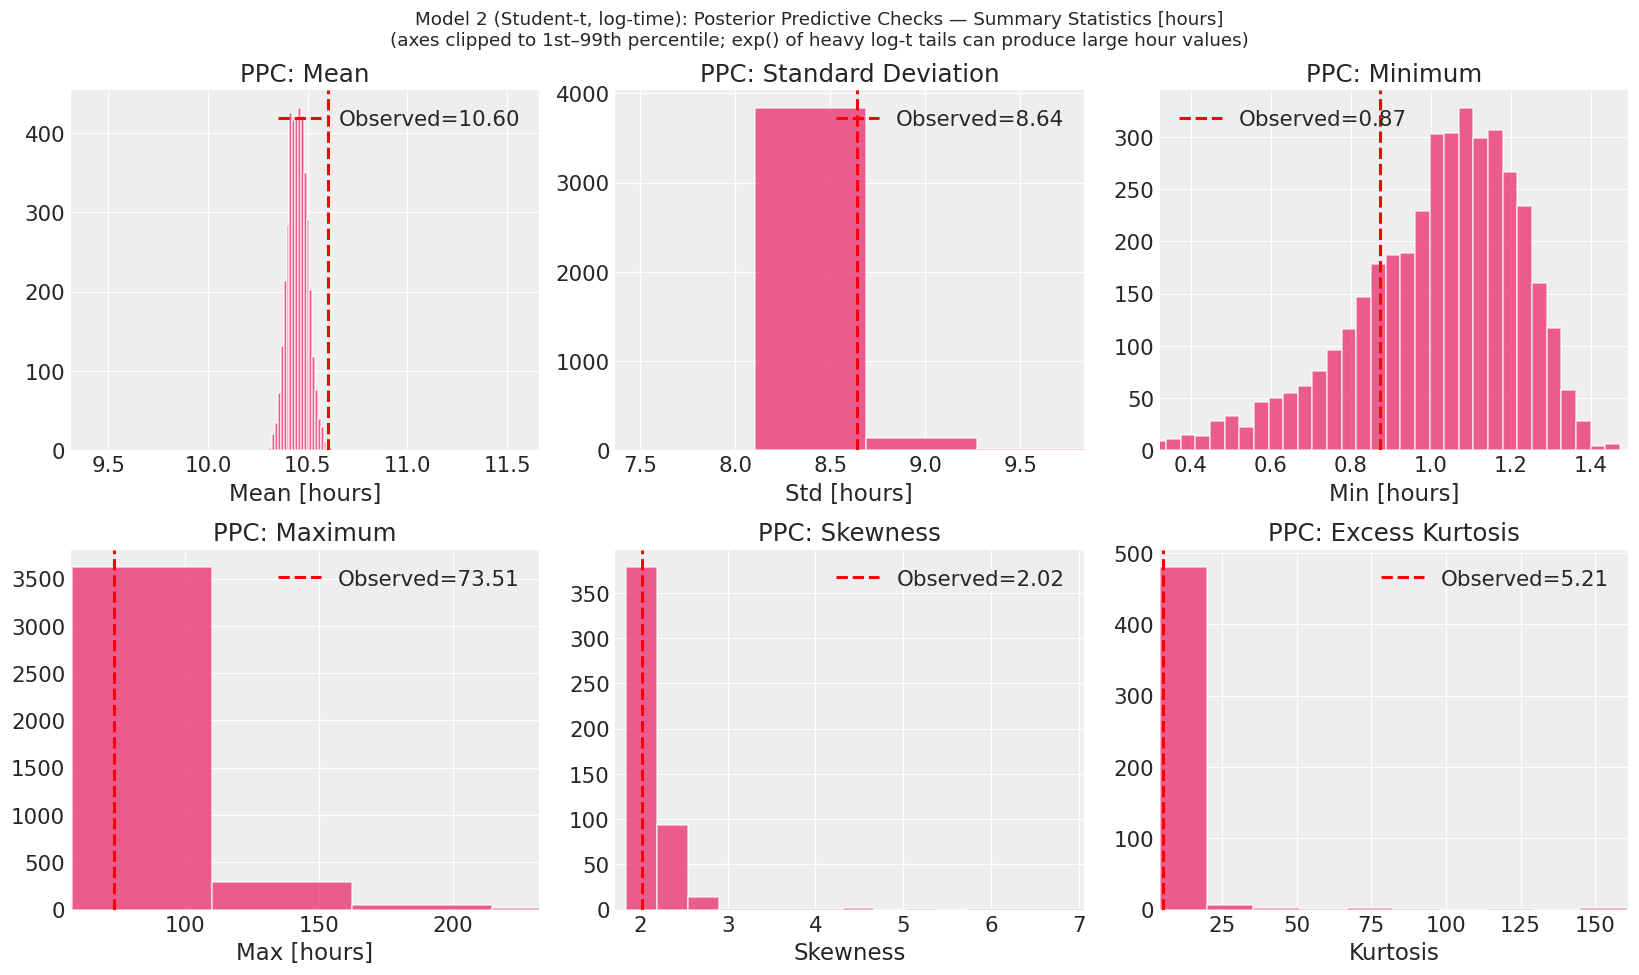

In [9]:
# Posterior predictive — summary statistics (on the HOUR scale via time_rep = exp(log_time_rep))
y_rep_samples = time_rep_samples
n_samples = y_rep_samples.shape[0]

pp_means = y_rep_samples.mean(axis=1)
pp_stds = y_rep_samples.std(axis=1)
pp_mins = y_rep_samples.min(axis=1)
pp_maxs = y_rep_samples.max(axis=1)
pp_skew = np.array([stats.skew(y_rep_samples[s]) for s in range(min(500, n_samples))])

# Helper: compute xlim from data using percentiles (handles extreme Student-t tails)
def robust_xlim(sim_vals, obs_val, pct_lo=1, pct_hi=99):
    lo = min(np.percentile(sim_vals, pct_lo), obs_val) * 1.1 if min(np.percentile(sim_vals, pct_lo), obs_val) < 0 else min(np.percentile(sim_vals, pct_lo), obs_val) * 0.9
    hi = max(np.percentile(sim_vals, pct_hi), obs_val) * 1.1
    return (lo, hi)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0,0].hist(pp_means, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[0,0].axvline(y_obs.mean(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.mean():.2f}')
axes[0,0].set_title('PPC: Mean')
axes[0,0].set_xlabel('Mean [hours]')
axes[0,0].set_xlim(robust_xlim(pp_means, y_obs.mean()))
axes[0,0].legend()

axes[0,1].hist(pp_stds, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[0,1].axvline(y_obs.std(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.std():.2f}')
axes[0,1].set_title('PPC: Standard Deviation')
axes[0,1].set_xlabel('Std [hours]')
axes[0,1].set_xlim(robust_xlim(pp_stds, y_obs.std()))
axes[0,1].legend()

axes[0,2].hist(pp_mins, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[0,2].axvline(y_obs.min(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.min():.2f}')
axes[0,2].set_title('PPC: Minimum')
axes[0,2].set_xlabel('Min [hours]')
axes[0,2].set_xlim(robust_xlim(pp_mins, y_obs.min()))
axes[0,2].legend()

axes[1,0].hist(pp_maxs, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[1,0].axvline(y_obs.max(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.max():.2f}')
axes[1,0].set_title('PPC: Maximum')
axes[1,0].set_xlabel('Max [hours]')
axes[1,0].set_xlim(robust_xlim(pp_maxs, y_obs.max()))
axes[1,0].legend()

axes[1,1].hist(pp_skew, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[1,1].axvline(stats.skew(y_obs), color='red', linewidth=2, linestyle='--', label=f'Observed={stats.skew(y_obs):.2f}')
axes[1,1].set_title('PPC: Skewness')
axes[1,1].set_xlabel('Skewness')
axes[1,1].set_xlim(robust_xlim(pp_skew, stats.skew(y_obs)))
axes[1,1].legend()

# Kurtosis — key for Student-t
pp_kurt = np.array([stats.kurtosis(y_rep_samples[s]) for s in range(min(500, n_samples))])
axes[1,2].hist(pp_kurt, bins=40, color='#E91E63', alpha=0.7, edgecolor='white')
axes[1,2].axvline(stats.kurtosis(y_obs), color='red', linewidth=2, linestyle='--', label=f'Observed={stats.kurtosis(y_obs):.2f}')
axes[1,2].set_title('PPC: Excess Kurtosis')
axes[1,2].set_xlabel('Kurtosis')
axes[1,2].set_xlim(robust_xlim(pp_kurt, stats.kurtosis(y_obs)))
axes[1,2].legend()

plt.suptitle('Model 2 (Student-t, log-time): Posterior Predictive Checks — Summary Statistics [hours]\n(axes clipped to 1st–99th percentile; exp() of heavy log-t tails can produce large hour values)', fontsize=12)
plt.tight_layout()
plt.savefig('fig13_model2_ppc_stats.png', bbox_inches='tight')
plt.show()

## 4.3 Data Consistency Assessment

In [10]:
# Quantitative assessment
print("Model 2 (Student-t) — Posterior Predictive Consistency Check")
print("=" * 65)

def ppc_pvalue(observed_stat, simulated_stats):
    return np.mean(simulated_stats >= observed_stat)

stats_check = [
    ('Mean', y_obs.mean(), pp_means),
    ('Std Dev', y_obs.std(), pp_stds),
    ('Minimum', y_obs.min(), pp_mins),
    ('Maximum', y_obs.max(), pp_maxs),
    ('Skewness', stats.skew(y_obs), pp_skew),
    ('Kurtosis', stats.kurtosis(y_obs), pp_kurt),
]

print(f"{'Statistic':<15} {'Observed':<12} {'PP Median':<12} {'PP 95% CI':<25} {'p-value':<10} {'Status'}")
print("-" * 85)
for name, obs_val, pp_vals in stats_check:
    pp_med = np.median(pp_vals)
    pp_lo = np.percentile(pp_vals, 2.5)
    pp_hi = np.percentile(pp_vals, 97.5)
    pval = ppc_pvalue(obs_val, pp_vals)
    in_ci = pp_lo <= obs_val <= pp_hi
    status = '✓ consistent' if in_ci else '✗ INCONSISTENT'
    print(f"{name:<15} {obs_val:<12.3f} {pp_med:<12.3f} [{pp_lo:.2f}, {pp_hi:.2f}]{'':>5} {pval:<10.3f} {status}")

print("\n" + "=" * 65)
print("Interpretation:")
print("  - Student-t should better capture kurtosis (heavy tails)")
print("  - May also better capture maximum values (extreme races)")
print("  - If nu is small (<10), the model has substantially heavier tails than Normal")

Model 2 (Student-t) — Posterior Predictive Consistency Check
Statistic       Observed     PP Median    PP 95% CI                 p-value    Status
-------------------------------------------------------------------------------------
Mean            10.600       10.450       [10.36, 10.55]      0.002      ✗ INCONSISTENT
Std Dev         8.640        8.430        [8.22, 8.75]      0.064      ✓ consistent
Minimum         0.873        1.046        [0.48, 1.32]      0.771      ✓ consistent
Maximum         73.507       80.545       [65.85, 153.32]      0.761      ✓ consistent
Skewness        2.025        2.100        [1.93, 3.27]      0.756      ✓ consistent
Kurtosis        5.209        6.558        [4.91, 32.11]      0.924      ✓ consistent

Interpretation:
  - Student-t should better capture kurtosis (heavy tails)
  - May also better capture maximum values (extreme races)
  - If nu is small (<10), the model has substantially heavier tails than Normal


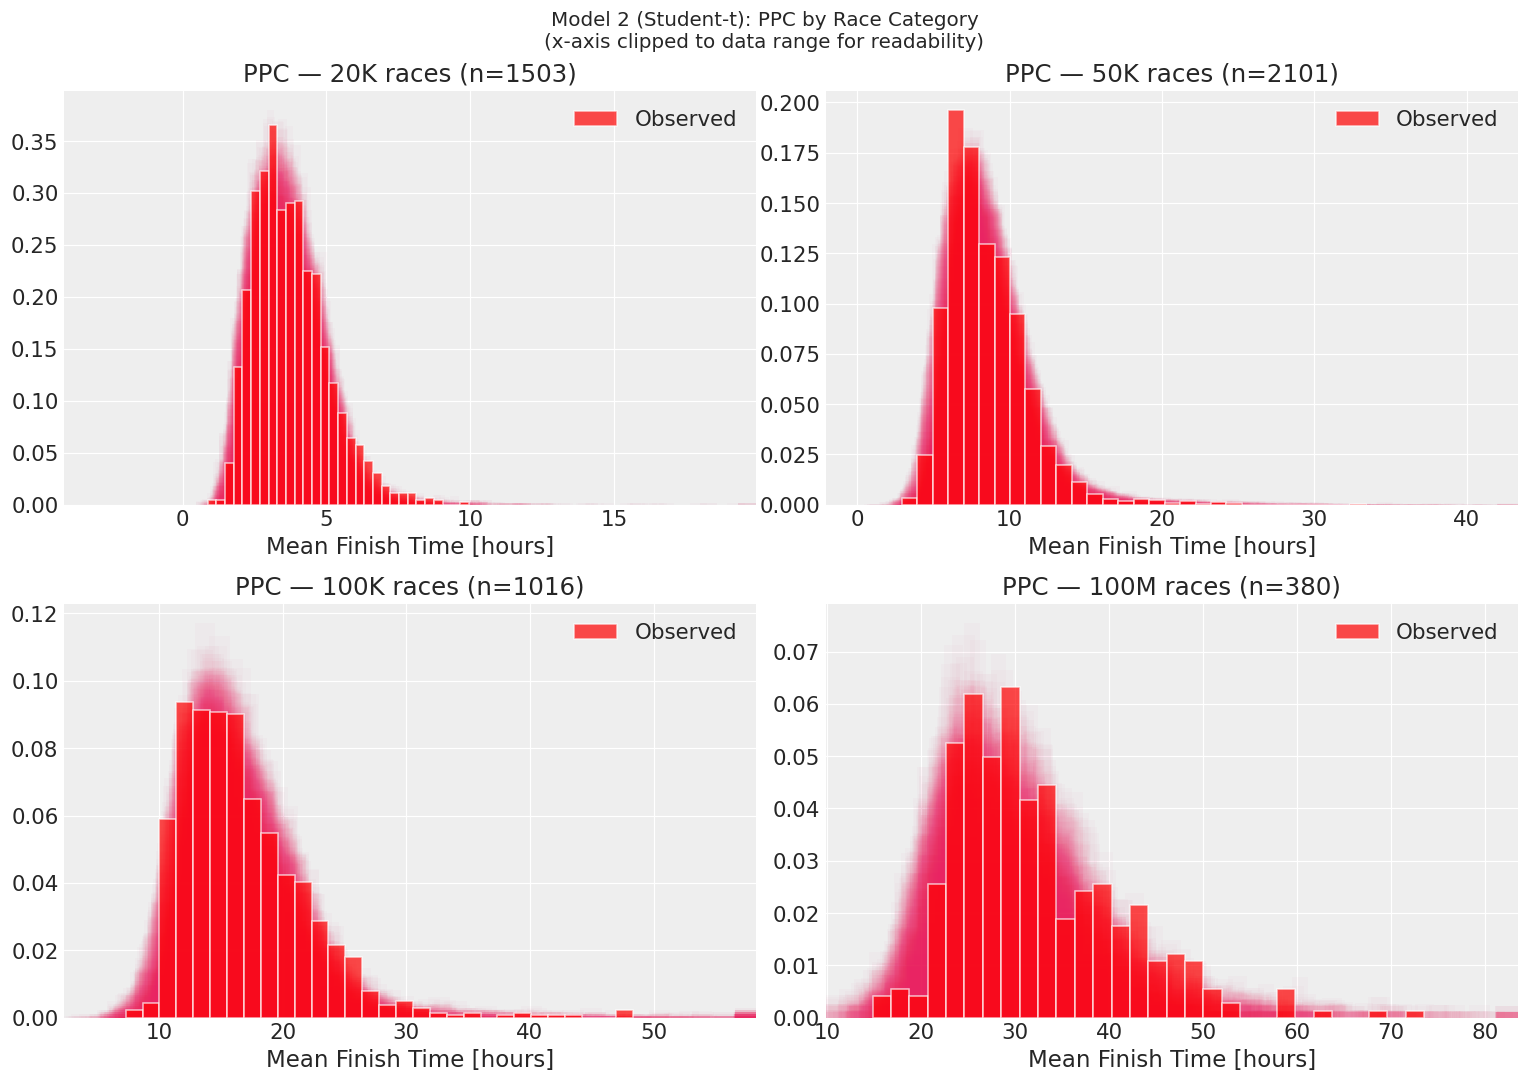

In [11]:
# PPC by race category
categories = ['20K', '50K', '100K', '100M']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, cat in enumerate(categories):
    ax = axes[idx // 2, idx % 2]
    mask = df['Race Category'].values == cat
    y_cat = y_obs[mask]
    y_rep_cat = y_rep_samples[:500, mask]
    
    # Clip y_rep for visualization (ν≈1.7 generates extreme values)
    clip_lo = y_cat.min() - 5
    clip_hi = y_cat.max() + 10
    
    for s in range(min(100, y_rep_cat.shape[0])):
        y_rep_clipped = np.clip(y_rep_cat[s], clip_lo, clip_hi)
        ax.hist(y_rep_clipped, bins=30, density=True, alpha=0.02, color='#E91E63')
    ax.hist(y_cat, bins=30, density=True, alpha=0.7, color='red', edgecolor='white', label='Observed')
    ax.set_title(f'PPC — {cat} races (n={mask.sum()})')
    ax.set_xlabel('Mean Finish Time [hours]')
    ax.set_xlim(clip_lo, clip_hi)
    ax.legend()

plt.suptitle('Model 2 (Student-t): PPC by Race Category\n(x-axis clipped to data range for readability)', fontsize=13)
plt.tight_layout()
plt.savefig('fig14_model2_ppc_categories.png', bbox_inches='tight')
plt.show()

## 4.4 Marginal Posterior Distributions

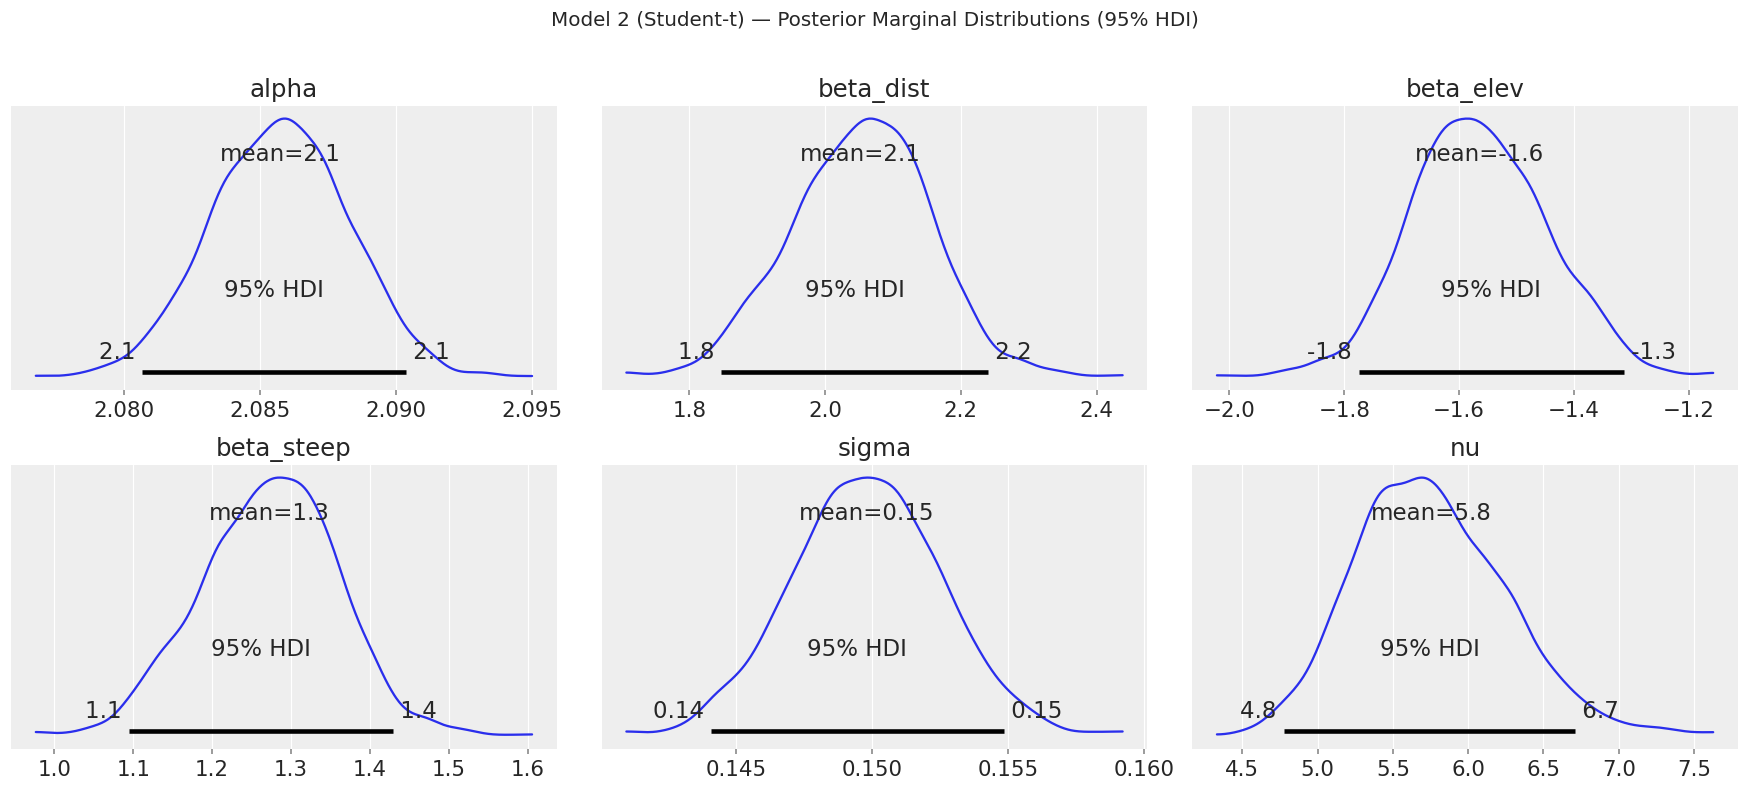

In [12]:
# Posterior marginals
fig = az.plot_posterior(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma', 'nu'],
                        figsize=(16, 7), hdi_prob=0.95)
plt.suptitle('Model 2 (Student-t) — Posterior Marginal Distributions (95% HDI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig15_model2_posteriors.png', bbox_inches='tight')
plt.show()

In [13]:
# Detailed parameter analysis (log-time scale; exp() gives multiplicative effects)
print("Model 2 (Student-t, log-time) — Parameter Interpretation")
print("=" * 65)

alpha_post = idata2.posterior['alpha'].values.flatten()
beta_dist_post = idata2.posterior['beta_dist'].values.flatten()
beta_elev_post = idata2.posterior['beta_elev'].values.flatten()
beta_steep_post = idata2.posterior['beta_steep'].values.flatten()
sigma_post = idata2.posterior['sigma'].values.flatten()
nu_post = idata2.posterior['nu'].values.flatten()

print(f"\n--- alpha (intercept, log scale) ---")
print(f"  Posterior mean: {alpha_post.mean():.3f}  =>  exp(alpha) = {np.exp(alpha_post.mean()):.2f} h")
print(f"  95% HDI (hours): [{np.exp(np.percentile(alpha_post, 2.5)):.2f}, {np.exp(np.percentile(alpha_post, 97.5)):.2f}]")

print(f"\n--- beta_dist (log-distance effect) ---")
print(f"  Posterior mean: {beta_dist_post.mean():.3f}  =>  x{np.exp(beta_dist_post.mean()):.2f} per +1 SD")
print(f"  95% HDI: [{np.percentile(beta_dist_post, 2.5):.3f}, {np.percentile(beta_dist_post, 97.5):.3f}]")

print(f"\n--- beta_elev (log-elevation effect) ---")
print(f"  Posterior mean: {beta_elev_post.mean():.3f}  =>  x{np.exp(beta_elev_post.mean()):.2f} per +1 SD")
print(f"  95% HDI: [{np.percentile(beta_elev_post, 2.5):.3f}, {np.percentile(beta_elev_post, 97.5):.3f}]")

print(f"\n--- beta_steep (steepness effect) ---")
print(f"  Posterior mean: {beta_steep_post.mean():.3f}  =>  x{np.exp(beta_steep_post.mean()):.2f} per +1 SD")
print(f"  95% HDI: [{np.percentile(beta_steep_post, 2.5):.3f}, {np.percentile(beta_steep_post, 97.5):.3f}]")
print(f"  P(beta_steep > 0): {(beta_steep_post > 0).mean():.4f}")

print(f"\n--- sigma (scale, log scale) ---")
print(f"  Posterior mean: {sigma_post.mean():.3f}")
print(f"  95% HDI: [{np.percentile(sigma_post, 2.5):.3f}, {np.percentile(sigma_post, 97.5):.3f}]")

print(f"\n--- nu (degrees of freedom) ---")
print(f"  Posterior mean: {nu_post.mean():.2f}")
print(f"  Posterior median: {np.median(nu_post):.2f}")
print(f"  95% HDI: [{np.percentile(nu_post, 2.5):.2f}, {np.percentile(nu_post, 97.5):.2f}]")
print(f"  P(nu < 10): {(nu_post < 10).mean():.3f}")
print(f"  P(nu < 30): {(nu_post < 30).mean():.3f}")

if np.median(nu_post) < 30:
    print(f"\n  → nu is relatively small: log-time has heavier tails than Normal.")
    print(f"  → The Student-t model captures outlier races without inflating sigma.")
else:
    print(f"\n  → nu is large: log-time is approximately Normal.")
    print(f"  → The Student-t model reduces to approximately the Normal log-time model.")

print(f"\n--- Concentration/Diffusion ---")
print(f"  alpha CV:      {alpha_post.std()/abs(alpha_post.mean())*100:.1f}%")
print(f"  beta_dist CV:  {beta_dist_post.std()/abs(beta_dist_post.mean())*100:.1f}%")
print(f"  beta_elev CV:  {beta_elev_post.std()/abs(beta_elev_post.mean())*100:.1f}%")
print(f"  beta_steep CV: {beta_steep_post.std()/abs(beta_steep_post.mean())*100:.1f}%")
print(f"  sigma CV:      {sigma_post.std()/abs(sigma_post.mean())*100:.1f}%")
print(f"  nu CV:         {nu_post.std()/abs(nu_post.mean())*100:.1f}%")

Model 2 (Student-t, log-time) — Parameter Interpretation

--- alpha (intercept, log scale) ---
  Posterior mean: 2.086  =>  exp(alpha) = 8.05 h
  95% HDI (hours): [8.01, 8.09]

--- beta_dist (log-distance effect) ---
  Posterior mean: 2.052  =>  x7.78 per +1 SD
  95% HDI: [1.850, 2.244]

--- beta_elev (log-elevation effect) ---
  Posterior mean: -1.565  =>  x0.21 per +1 SD
  95% HDI: [-1.791, -1.328]

--- beta_steep (steepness effect) ---
  Posterior mean: 1.273  =>  x3.57 per +1 SD
  95% HDI: [1.101, 1.438]
  P(beta_steep > 0): 1.0000

--- sigma (scale, log scale) ---
  Posterior mean: 0.150
  95% HDI: [0.144, 0.155]

--- nu (degrees of freedom) ---
  Posterior mean: 5.75
  Posterior median: 5.72
  95% HDI: [4.86, 6.82]
  P(nu < 10): 1.000
  P(nu < 30): 1.000

  → nu is relatively small: log-time has heavier tails than Normal.
  → The Student-t model captures outlier races without inflating sigma.

--- Concentration/Diffusion ---
  alpha CV:      0.1%
  beta_dist CV:  5.0%
  beta_elev

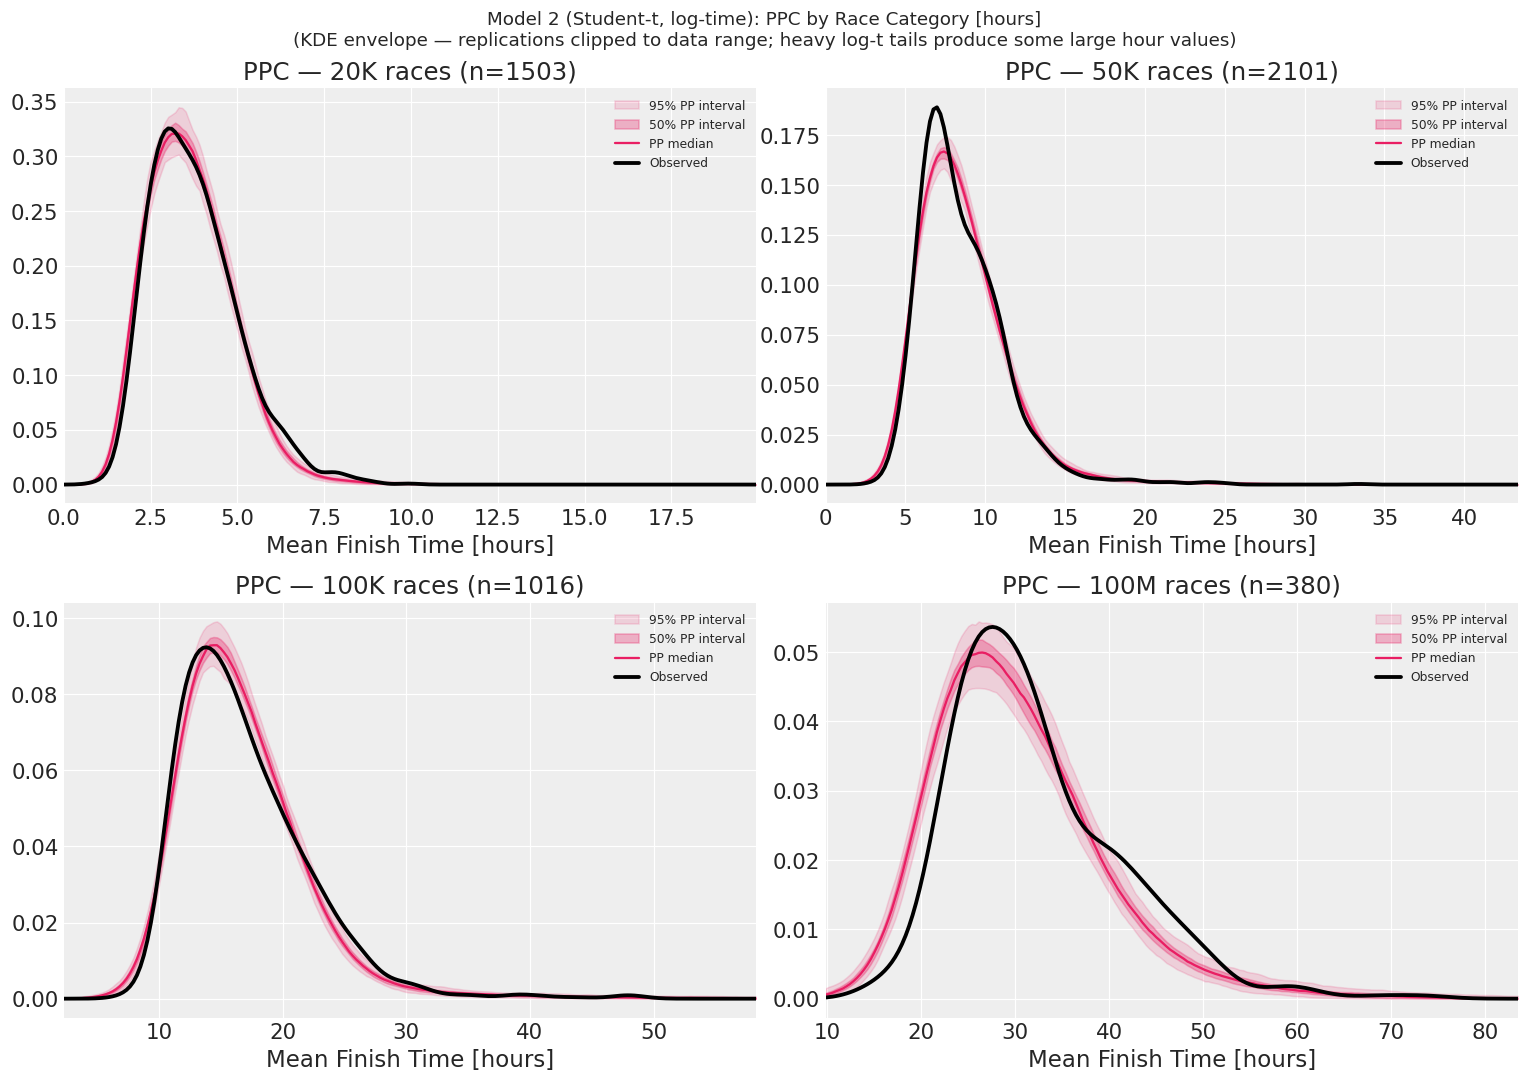

In [14]:
# PPC by race category — KDE envelope visualization
from scipy.stats import gaussian_kde

categories = ['20K', '50K', '100K', '100M']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, cat in enumerate(categories):
    ax = axes[idx // 2, idx % 2]
    mask = df['Race Category'].values == cat
    y_cat = y_obs[mask]
    y_rep_cat = y_rep_samples[:500, mask]
    
    # Clip y_rep for KDE (ν≈1.7 generates extreme values)
    clip_lo = max(0, y_cat.min() - 5)
    clip_hi = y_cat.max() + 10
    x_grid = np.linspace(clip_lo, clip_hi, 200)
    
    kde_curves = []
    for s in range(min(150, y_rep_cat.shape[0])):
        y_clipped = y_rep_cat[s][(y_rep_cat[s] > clip_lo - 5) & (y_rep_cat[s] < clip_hi + 10)]
        if len(y_clipped) > 10:
            try:
                kde = gaussian_kde(y_clipped)
                kde_curves.append(kde(x_grid))
            except:
                pass
    kde_curves = np.array(kde_curves)
    
    kde_lo = np.percentile(kde_curves, 2.5, axis=0)
    kde_hi = np.percentile(kde_curves, 97.5, axis=0)
    kde_50lo = np.percentile(kde_curves, 25, axis=0)
    kde_50hi = np.percentile(kde_curves, 75, axis=0)
    kde_med = np.median(kde_curves, axis=0)
    
    ax.fill_between(x_grid, kde_lo, kde_hi, alpha=0.15, color='#E91E63', label='95% PP interval')
    ax.fill_between(x_grid, kde_50lo, kde_50hi, alpha=0.3, color='#E91E63', label='50% PP interval')
    ax.plot(x_grid, kde_med, color='#E91E63', linewidth=1.5, label='PP median')
    
    kde_obs = gaussian_kde(y_cat)
    ax.plot(x_grid, kde_obs(x_grid), color='black', linewidth=2.5, label='Observed')
    
    ax.set_title(f'PPC — {cat} races (n={mask.sum()})')
    ax.set_xlabel('Mean Finish Time [hours]')
    ax.set_xlim(clip_lo, clip_hi)
    ax.legend(fontsize=8, framealpha=0.9)

plt.suptitle('Model 2 (Student-t, log-time): PPC by Race Category [hours]\n(KDE envelope — replications clipped to data range; heavy log-t tails produce some large hour values)', fontsize=12)
plt.tight_layout()
plt.savefig('fig14_model2_ppc_categories.png', dpi=150, bbox_inches='tight')
plt.show()

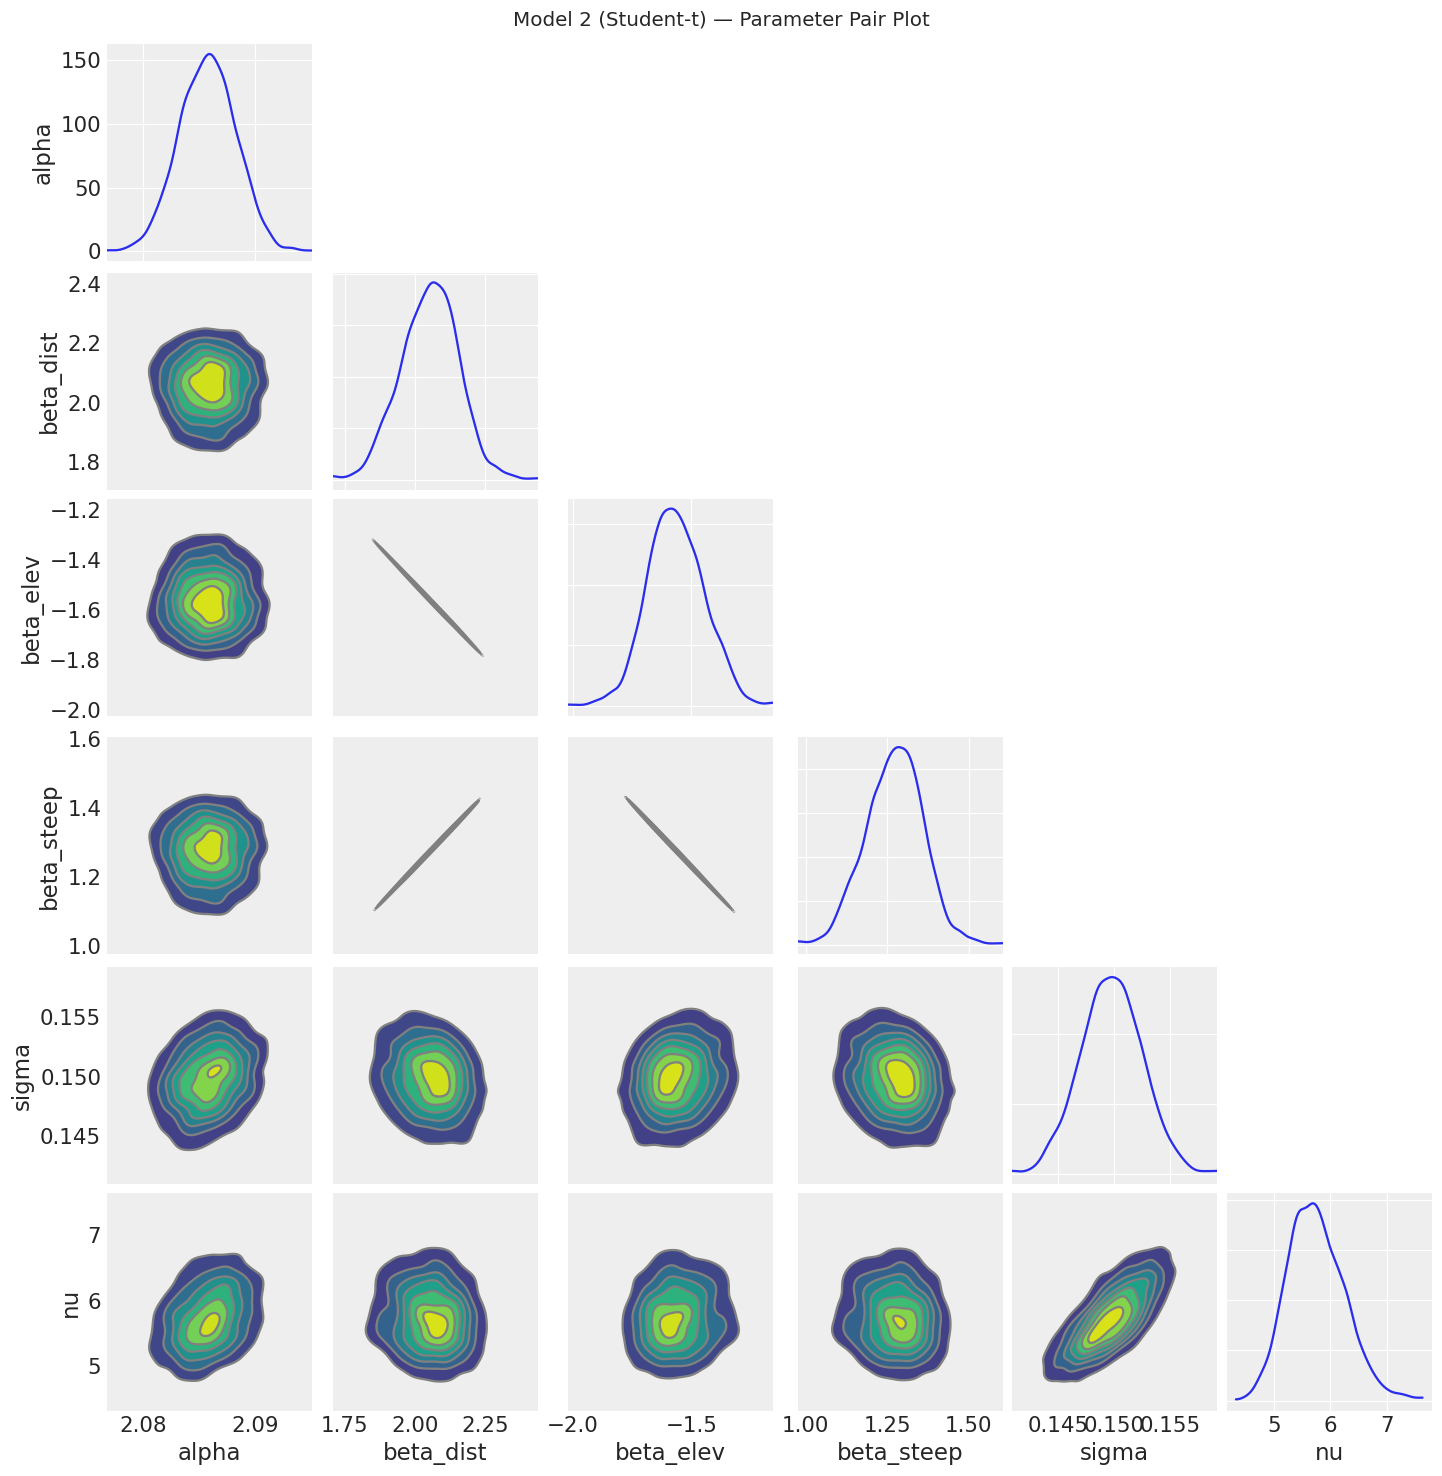


Pair plot assessment:
  → Check sigma-nu correlation: negative correlation is expected
    (smaller nu = heavier tails → may allow smaller sigma)
  → Other parameters should be relatively independent


In [15]:
# Pair plot for Model 2
fig = az.plot_pair(idata2, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma', 'nu'],
                   kind='kde', figsize=(13, 13), marginals=True)
plt.suptitle('Model 2 (Student-t) — Parameter Pair Plot', fontsize=13, y=1.02)
plt.savefig('fig17_model2_pairs.png', bbox_inches='tight')
plt.show()

print("\nPair plot assessment:")
print("  → Check sigma-nu correlation: negative correlation is expected")
print("    (smaller nu = heavier tails → may allow smaller sigma)")
print("  → Other parameters should be relatively independent")

## 4.5 Model 2 Summary

### Key Findings

1. **Degrees of freedom ($\nu$)**: The posterior for $\nu$ (with the hard floor $\nu>2$) tells us about tail heaviness of **log-time**
   - $\nu$ small (close to 2-10): strong evidence for heavy log-tails — Student-t clearly beneficial
   - $\nu$ moderate (10-30): some evidence for heavier-than-Normal log-tails
   - $\nu$ large (> 50): log-time is approximately Normal, models are equivalent

2. **Sigma comparison** (both on the **log scale**): Student-t typically has smaller $\sigma$ than the Normal log-time model because:
   - The Normal must inflate $\sigma$ to cover outlier log-times
   - The Student-t handles them via heavy tails ($\nu$) without affecting the bulk

3. **Steepness ($\beta_{steep}$)**: captures terrain difficulty (elevation per km) beyond raw distance/elevation; a positive value means steeper courses take multiplicatively longer.

4. **Positivity & interpretation**: predictions are produced as `time_rep = exp(log_time_rep)`, so they are strictly positive, and the $\beta$'s are multiplicative time factors.

### Comparison with Model 1

The formal model comparison (LOO, WAIC) — using `log_lik` evaluated on `log_time` for **both** models — is performed in Notebook 5.